In [1]:
# --- Cell 1: imports + shared config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.training.train_loop import train_model
from task2.methods.source_only import SourceOnly

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False)
DATA_ROOT = '../../datasets/PACS'
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

cuda NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# --- Cell 2: loaders from the frozen splits ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"source train imgs={loaders['n_source_train']}  target imgs={loaders['n_target']}")
print(f"steps/epoch={loaders['steps_per_epoch']}  (24 source images per step)")

source train imgs=4849  target imgs=3929
steps/epoch=203  (24 source images per step)


In [3]:
# --- Cell 3: VERIFICATION —  ---
from task2.backbones.backbone import set_train_mode
import torch.nn.functional as F
from shared.pacs_protocol import next_source_batch

probe = PACSModel(num_classes=7).to(device)
bn = [m for m in probe.modules() if isinstance(m, torch.nn.BatchNorm2d)]
before = bn[0].running_mean.clone()

set_train_mode(probe)
x, y = next_source_batch(loaders['source_train'], device)
F.cross_entropy(probe(x)[0], y).backward()          # one full forward+backward

after = bn[0].running_mean
print('BN modules:', len(bn), '| all in eval mode:', all(not m.training for m in bn))
print('running_mean changed:', not torch.allclose(before, after))   # must be False
print('gamma still trainable:', bn[0].weight.requires_grad)          # must be True
del probe, x, y; torch.cuda.empty_cache()

BN modules: 20 | all in eval mode: True
running_mean changed: False
gamma still trainable: True


In [4]:
# --- Cell 4: train source-only ERM ---
set_seed(6304)
loaders = build_loaders(DATA_ROOT, splits,          # rebuild: diagnostic cells consume
                        batch_per_source=CFG['batch_per_source'],   # batches, so training order
                        target_batch=CFG['target_batch'],           # must not depend on what
                        eval_batch=CFG['eval_batch'],               # ran before it
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = SourceOnly(CFG)
out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_source_only.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=0.5346 loss_cls=0.5346 train_acc=0.8118 | val photo=0.913 art_painting=0.837 cartoon=0.916 mean_f1=0.8886 | 23s
ep02 loss_total=0.2295 loss_cls=0.2295 train_acc=0.9212 | val photo=0.959 art_painting=0.801 cartoon=0.901 mean_f1=0.8869 | 48s
ep03 loss_total=0.1747 loss_cls=0.1747 train_acc=0.9427 | val photo=0.959 art_painting=0.870 cartoon=0.944 mean_f1=0.9239 | 77s
ep04 loss_total=0.1253 loss_cls=0.1253 train_acc=0.9557 | val photo=0.953 art_painting=0.861 cartoon=0.946 mean_f1=0.9202 | 105s
ep05 loss_total=0.1020 loss_cls=0.1020 train_acc=0.9626 | val photo=0.934 art_painting=0.848 cartoon=0.920 mean_f1=0.9004 | 136s
ep06 loss_total=0.0934 loss_cls=0.0934 train_acc=0.9680 | val photo=0.963 art_painting=0.890 cartoon=0.955 mean_f1=0.9358 | 166s
ep07 loss_total=0.0961 loss_cls=0.0961 train_acc=0.9672 | val photo=0.929 art_painting=0.858 cartoon=0.880 mean_f1=0.8892 | 197s
ep08 loss_total=0.0720 loss_cls=0.0720 train_acc=0.9758 | val photo=0.972 art_painting=0.895 cartoon

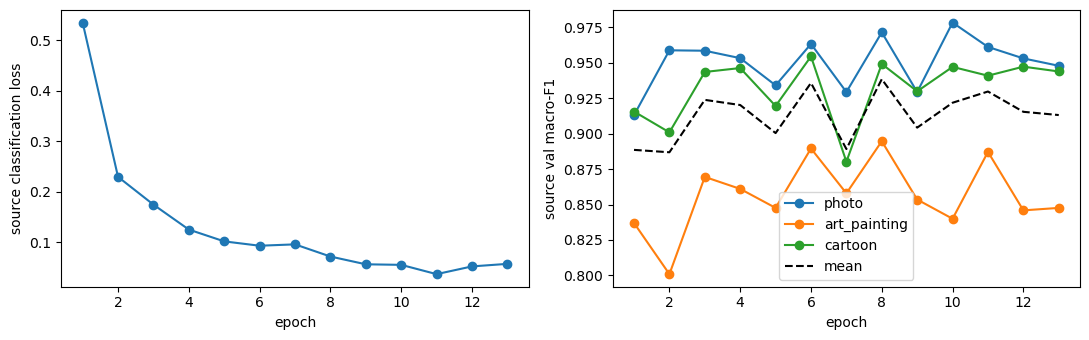

In [5]:
# --- Cell 5: save results  ---
results = {'step': 'source_only', 'seed': 6304, 'method': 'source_only',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/source_only.json')

import matplotlib.pyplot as plt
h = out['history']
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot([r['epoch'] for r in h], [r['loss_cls'] for r in h], marker='o')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('source classification loss')
for d in splits['source_domains']:
    ax[1].plot([r['epoch'] for r in h], [r['per_domain'][d]['macro_f1'] for r in h],
               marker='o', label=d)
ax[1].plot([r['epoch'] for r in h], [r['mean_macro_f1'] for r in h],
           'k--', label='mean')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('source val macro-F1'); ax[1].legend()
plt.tight_layout(); plt.savefig('../../report/figures/task2_source_only_curves.png', dpi=200)
plt.show()